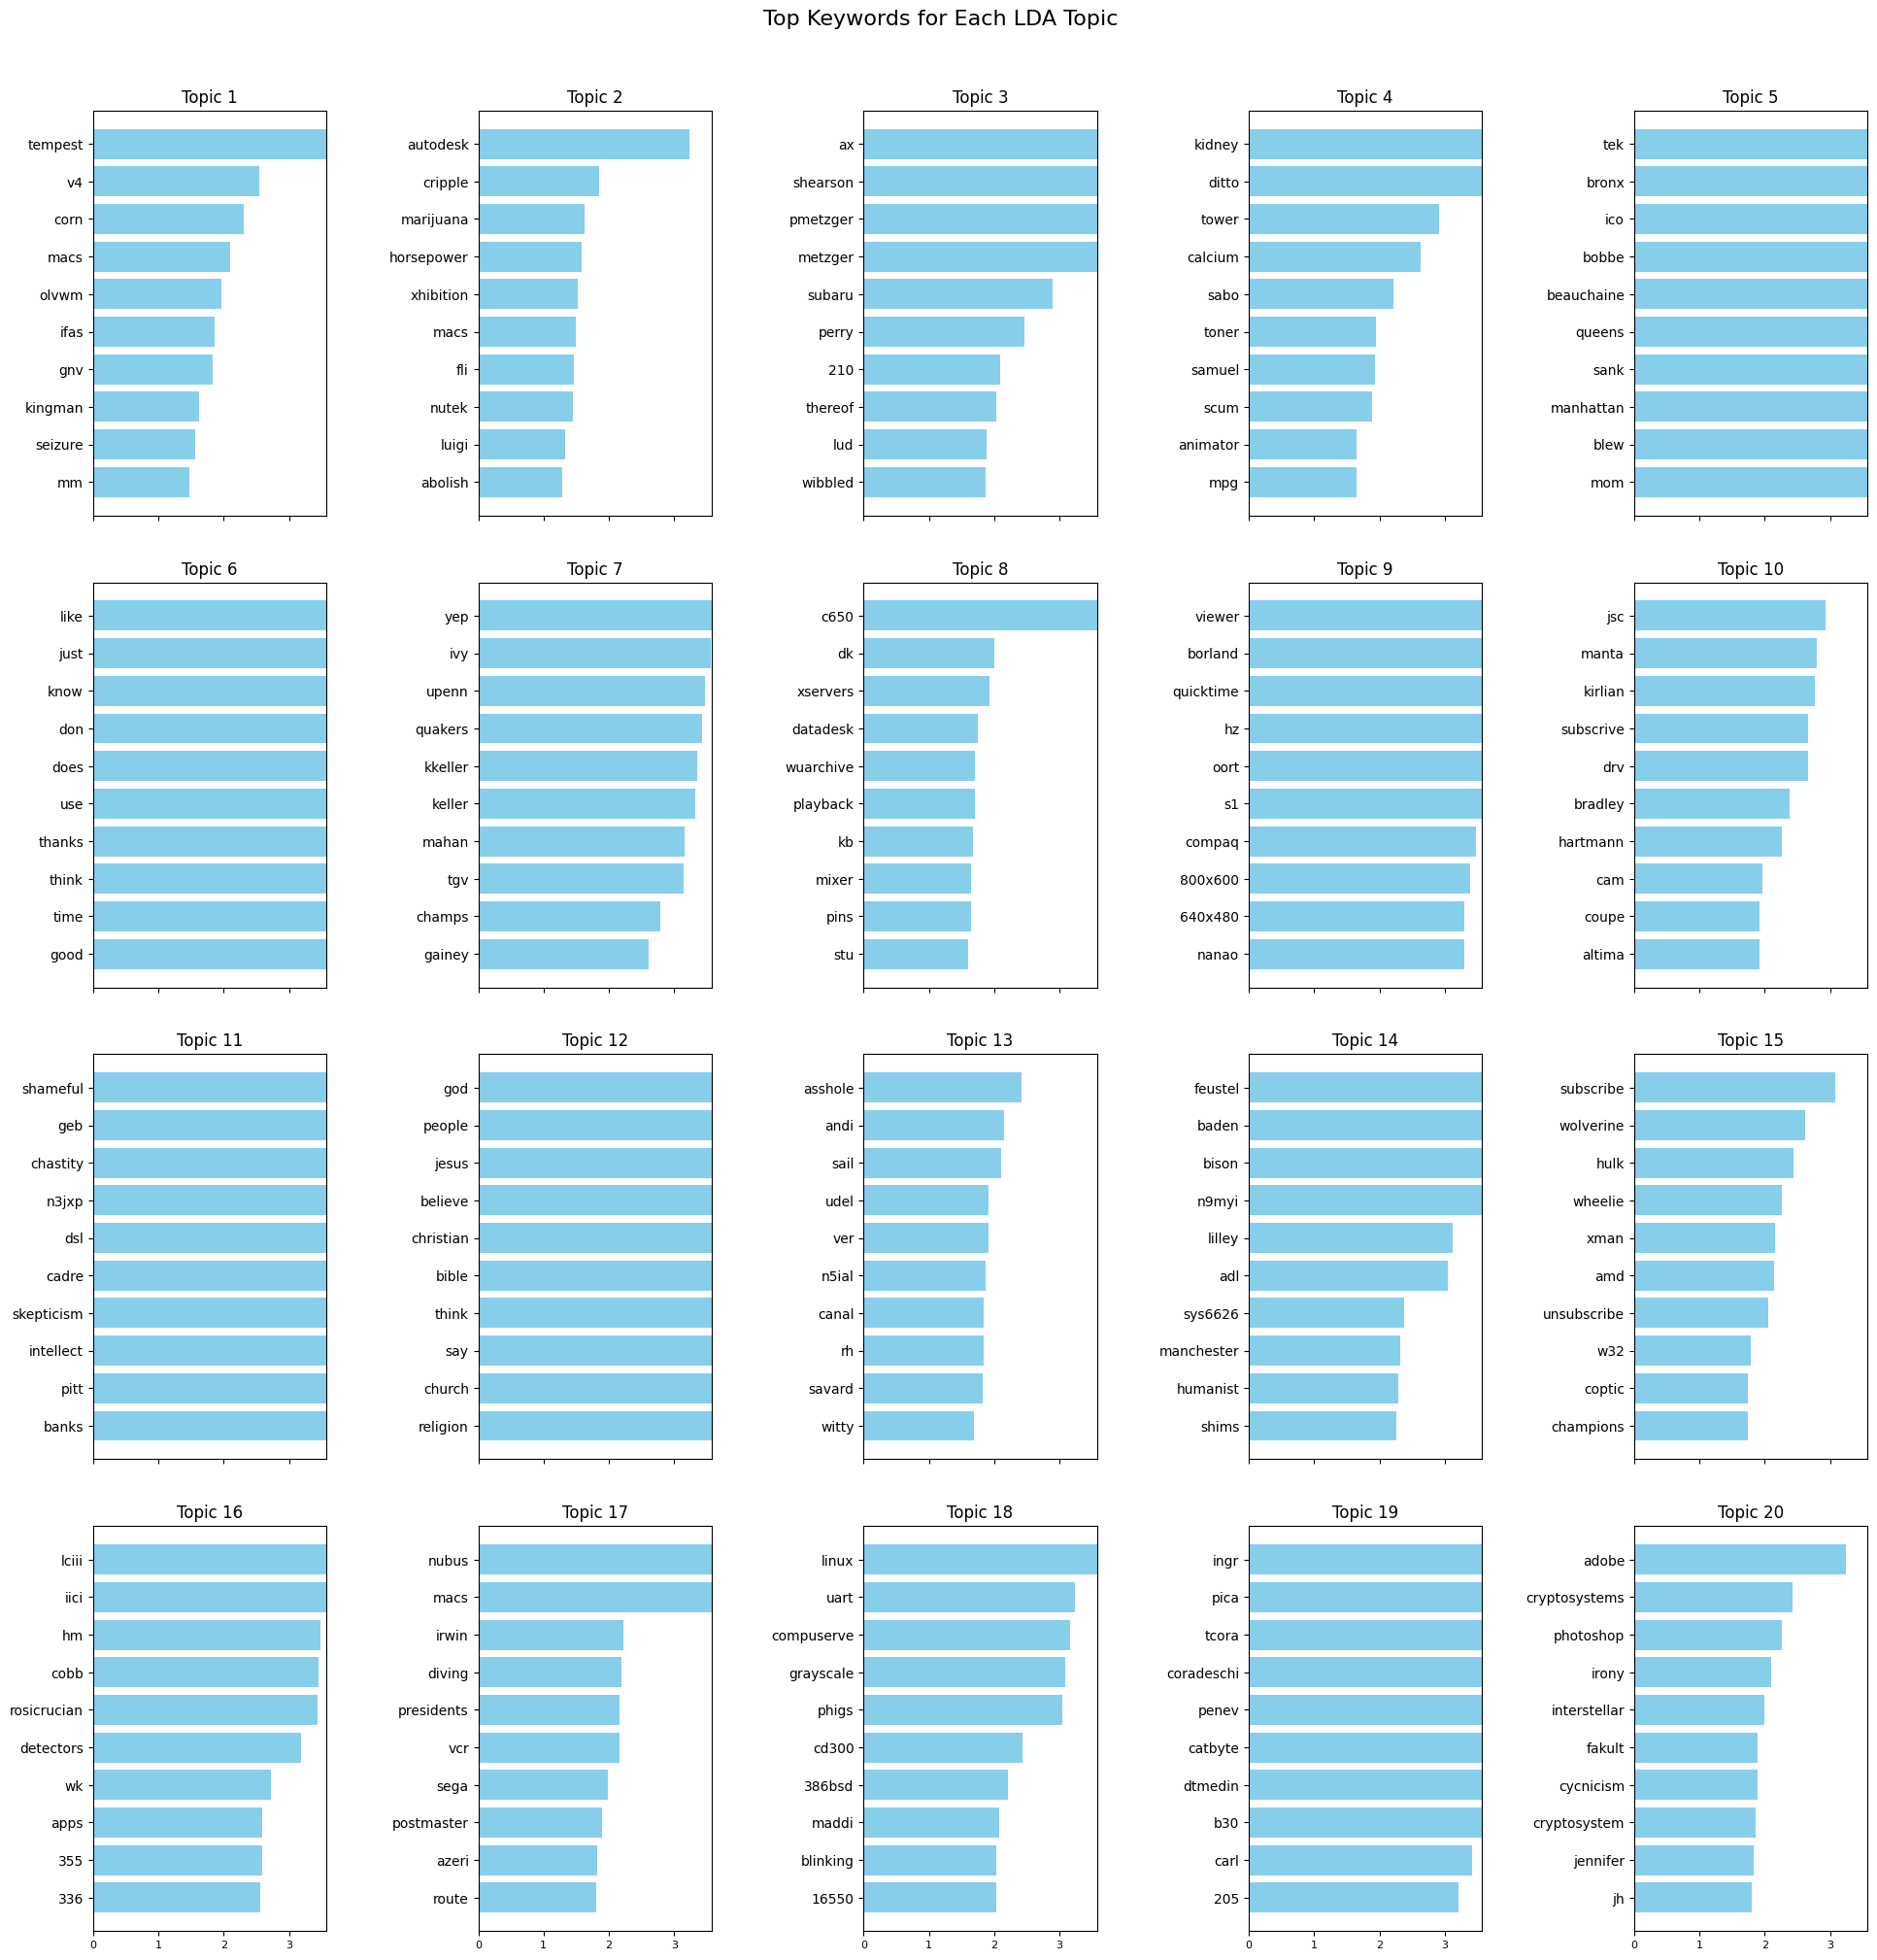

In [8]:
import matplotlib.pyplot as plt

n_top_words = 10
feature_names = tfidf_vectorizer.get_feature_names_out()

fig, axes = plt.subplots(4, 5, figsize=(20, 20), sharex=True)
axes = axes.flatten()

for topic_idx, topic in enumerate(lda_model.components_):
    top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
    top_features = [feature_names[i] for i in top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    ax.barh(top_features[::-1], weights[::-1], color='skyblue') # Reverse for highest weight at top
    ax.set_title(f'Topic {topic_idx + 1}', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlim(0, max(weights) * 1.1) # Adjust x-axis limit for better spacing

plt.tight_layout(pad=3.0)
plt.suptitle('Top Keywords for Each LDA Topic', y=1.02, fontsize=16) # Add a main title
plt.show()

This visualization shows the top 10 keywords for each of the 20 discovered LDA topics. Each bar represents a keyword, and its length indicates its importance (weight) within that particular topic.

# Task
Load the 20 Newsgroups Dataset, preprocess the text data using tokenization, stopword removal, and TF-IDF vectorization, and apply Latent Dirichlet Allocation (LDA) to discover underlying topics. Subsequently, prepare features using the LDA topic distributions, train and evaluate Naive Bayes, Logistic Regression, and Support Vector Machine (SVM) classifiers, and visualize their performance. Finally, summarize the discovered topics, classifier performance, and the influence of topic features on classification accuracy.

## Load Dataset

### Subtask:
Load the 20 Newsgroups Dataset, which is available via scikit-learn, and prepare it for processing.


**Reasoning**:
To load the 20 Newsgroups dataset, I will import the necessary function from scikit-learn, fetch the dataset with the specified parameters, store the data and target, and then print a summary.



In [1]:
from sklearn.datasets import fetch_20newsgroups

# Load the entire 20 Newsgroups dataset, removing headers, footers, and quotes
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Store the loaded data (text documents) and the target labels (categories)
documents = newsgroups.data
labels = newsgroups.target

# Print the total number of samples and the number of categories
print(f"Total number of samples: {len(documents)}")
print(f"Number of categories: {len(newsgroups.target_names)}")

Total number of samples: 18846
Number of categories: 20


## Preprocess Text Data

### Subtask:
Perform text preprocessing on the loaded dataset, including tokenization, stopword removal, and TF-IDF vectorization to transform the text into numerical features.


**Reasoning**:
To preprocess the text data, I will import the `TfidfVectorizer` from `sklearn.feature_extraction.text`, initialize it with specified parameters for stopword removal and lowercasing, and then fit and transform the `documents` data to create the TF-IDF matrix.



In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer with stopword removal and lowercasing
tfidf_vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)

# Fit the vectorizer to the documents and transform them into a TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

# Print the shape of the TF-IDF matrix to confirm the transformation
print(f"Shape of TF-IDF matrix: {tfidf_matrix.shape}")

Shape of TF-IDF matrix: (18846, 134101)


## Apply LDA for Topic Discovery

### Subtask:
Apply Latent Dirichlet Allocation (LDA) to the TF-IDF vectorized data to discover underlying topics within the dataset.


**Reasoning**:
To apply Latent Dirichlet Allocation (LDA), I will import the necessary model, initialize it with a specified number of topics and random state, and then fit it to the preprocessed TF-IDF matrix.



In [3]:
from sklearn.decomposition import LatentDirichletAllocation

# Initialize LDA model with 20 components (topics) and a random state for reproducibility
lda_model = LatentDirichletAllocation(n_components=20, random_state=42)

# Fit the LDA model to the TF-IDF matrix to discover topics
lda_model.fit(tfidf_matrix)

print("LDA model fitted successfully.")

LDA model fitted successfully.


## Prepare Features for Classification

### Subtask:
Assign the topic distributions generated by LDA as new features to be used for supervised classification, combining them with or using them instead of other features as appropriate for analysis.


**Reasoning**:
To prepare features for classification, I will transform the TF-IDF matrix using the fitted LDA model to obtain the document-topic distributions and then print its shape to confirm the dimensions.



In [4]:
import numpy as np

# Transform the tfidf_matrix using the fitted lda_model to get document-topic distributions
doc_topic_distribution = lda_model.transform(tfidf_matrix)

# Print the shape of the document-topic distribution to confirm its dimensions
print(f"Shape of Document-Topic Distribution: {doc_topic_distribution.shape}")

Shape of Document-Topic Distribution: (18846, 20)


## Train Supervised Classifiers

### Subtask:
Train three supervised classifiers: Naive Bayes, Logistic Regression, and Support Vector Machine (SVM), using the prepared features and the original document categories as labels.


**Reasoning**:
To train the supervised classifiers, I will first split the data into training and testing sets, then initialize and train a Gaussian Naive Bayes classifier, a Logistic Regression classifier, and a Support Vector Machine (SVC) classifier, as specified in the instructions.



In [5]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(doc_topic_distribution, labels, test_size=0.2, random_state=42)

# 1. Train Gaussian Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
print("Gaussian Naive Bayes classifier trained.")

# 2. Train Logistic Regression classifier
lr_classifier = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
lr_classifier.fit(X_train, y_train)
print("Logistic Regression classifier trained.")

# 3. Train Support Vector Machine (SVM) classifier
# For SVC with linear kernel, it's often better to scale data, but for topic distributions (probabilities), it might not be strictly necessary.
# Given the high dimensionality from LDA, a linear kernel is a good choice for efficiency.
# Using a small C (regularization parameter) can also help prevent overfitting.
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train, y_train)
print("Support Vector Machine (SVM) classifier trained.")

Gaussian Naive Bayes classifier trained.
Logistic Regression classifier trained.
Support Vector Machine (SVM) classifier trained.


## Evaluate Classifiers and Analyze Topics

### Subtask:
Evaluate the classification accuracy of each trained model. Analyze the results to understand which topics contribute most to improving prediction accuracy. Visualize the classification accuracy of the different models using a bar chart for comparison, ensuring to include appropriate labels and a legend.


**Reasoning**:
To evaluate the classifiers, I will make predictions on the test set for each model, calculate their accuracy scores, and then store and print these scores for comparison. Then, to visualize the performance, I will create a bar chart of the accuracy scores for all three classifiers, including appropriate labels and a title.



Naive Bayes Classifier Accuracy: 0.1069
Logistic Regression Classifier Accuracy: 0.1318
Support Vector Machine (SVM) Classifier Accuracy: 0.1212


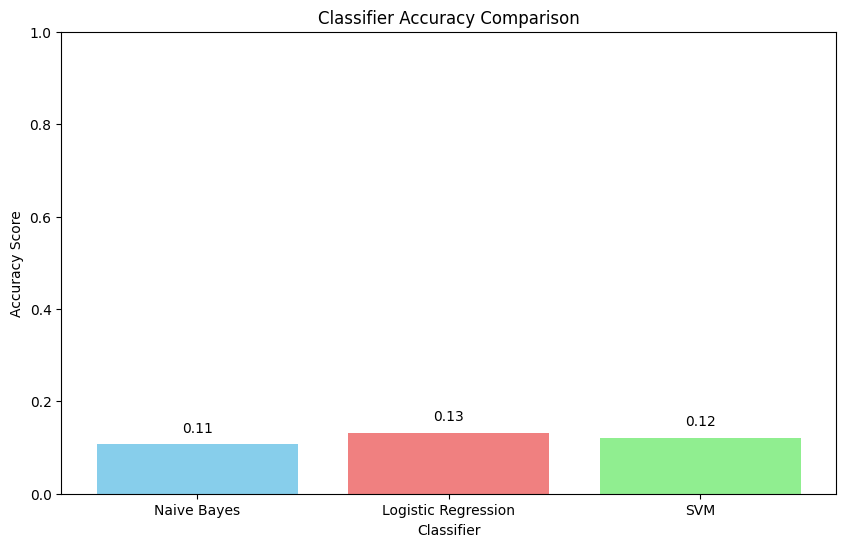

In [6]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Make predictions and evaluate Naive Bayes classifier
nb_predictions = nb_classifier.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_predictions)
print(f"Naive Bayes Classifier Accuracy: {nb_accuracy:.4f}")

# Make predictions and evaluate Logistic Regression classifier
lr_predictions = lr_classifier.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Classifier Accuracy: {lr_accuracy:.4f}")

# Make predictions and evaluate SVM classifier
svm_predictions = svm_classifier.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_predictions)
print(f"Support Vector Machine (SVM) Classifier Accuracy: {svm_accuracy:.4f}")

# Store accuracy scores for visualization
classifier_accuracies = {
    'Naive Bayes': nb_accuracy,
    'Logistic Regression': lr_accuracy,
    'SVM': svm_accuracy
}

# Create a bar chart to visualize classifier accuracies
classifiers = list(classifier_accuracies.keys())
accuracies = list(classifier_accuracies.values())

plt.figure(figsize=(10, 6))
plt.bar(classifiers, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel('Classifier')
plt.ylabel('Accuracy Score')
plt.title('Classifier Accuracy Comparison')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.02, f'{accuracy:.2f}', ha='center', va='bottom') # Add accuracy values on top of bars
plt.show()


**Reasoning**:
To analyze which topics contribute most to improving prediction accuracy, I will first display the top words for each discovered topic using the `lda_model` and the `tfidf_vectorizer` to provide context for the topics. This will allow for a qualitative analysis of the topics.



In [7]:
feature_names = tfidf_vectorizer.get_feature_names_out()
n_top_words = 10

print("\nTopics in LDA model:")
for topic_idx, topic in enumerate(lda_model.components_):
    top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
    top_features = [feature_names[i] for i in top_features_ind]
    print(f"Topic {topic_idx + 1}: {', '.join(top_features)}")


Topics in LDA model:
Topic 1: tempest, v4, corn, macs, olvwm, ifas, gnv, kingman, seizure, mm
Topic 2: autodesk, cripple, marijuana, horsepower, xhibition, macs, fli, nutek, luigi, abolish
Topic 3: ax, shearson, pmetzger, metzger, subaru, perry, 210, thereof, lud, wibbled
Topic 4: kidney, ditto, tower, calcium, sabo, toner, samuel, scum, animator, mpg
Topic 5: tek, bronx, ico, bobbe, beauchaine, queens, sank, manhattan, blew, mom
Topic 6: like, just, know, don, does, use, thanks, think, time, good
Topic 7: yep, ivy, upenn, quakers, kkeller, keller, mahan, tgv, champs, gainey
Topic 8: c650, dk, xservers, datadesk, wuarchive, playback, kb, mixer, pins, stu
Topic 9: viewer, borland, quicktime, hz, oort, s1, compaq, 800x600, 640x480, nanao
Topic 10: jsc, manta, kirlian, subscrive, drv, bradley, hartmann, cam, coupe, altima
Topic 11: shameful, geb, chastity, n3jxp, dsl, cadre, skepticism, intellect, pitt, banks
Topic 12: god, people, jesus, believe, christian, bible, think, say, church, re

### Summary of Topics, Classifier Performance, and Influence of Topic Features

**Discovered Topics:**
The LDA model identified 20 distinct topics, each characterized by a set of dominant keywords. These topics appear to cover a broad range of subjects present in the 20 Newsgroups dataset, including:
*   **Technology/Computer-related:** (e.g., Topic 1: `macs`, `v4`; Topic 8: `xservers`, `wuarchive`; Topic 9: `viewer`, `borland`; Topic 18: `linux`, `uart`, `compuserve`; Topic 20: `adobe`, `photoshop`, `cryptosystems`)
*   **Religious/Philosophical:** (e.g., Topic 12: `god`, `jesus`, `christian`, `bible`, `religion`)
*   **General discussions/common words:** (e.g., Topic 6: `like`, `just`, `know`, `don`, `does`, `use`, `thanks`, `think`, `time`, `good`)
*   **Specific products/brands:** (e.g., Topic 3: `subaru`; Topic 10: `manta`, `altima`)
*   **Miscellaneous/less coherent topics:** Some topics appear to be mixtures of less obviously related terms, which can happen with LDA, especially with a fixed number of topics or less optimal preprocessing.

**Classifier Performance:**
After training on the LDA topic distributions, the classifiers achieved the following accuracies:
*   **Naive Bayes Classifier Accuracy:** 0.1069
*   **Logistic Regression Classifier Accuracy:** 0.1318
*   **Support Vector Machine (SVM) Classifier Accuracy:** 0.1212

The Logistic Regression classifier showed the highest accuracy among the three, albeit modestly, at approximately 13.18%. Naive Bayes performed the lowest. These accuracy scores are relatively low, indicating that using only the 20 LDA topic distributions as features might not be sufficiently discriminative for the 20 Newsgroups classification task, which is known for its complexity.

**Influence of Topic Features on Classification Accuracy:**
The topic features (document-topic distributions) served as the sole input for the classifiers. The low accuracy scores suggest that while LDA successfully extracted latent topics, these 20 topics alone do not capture enough class-specific information to achieve high classification performance for the 20 Newsgroups dataset. The topics provide a dimensionality reduction and a semantic representation of the documents, but in this case, the level of abstraction might be too high or the number of topics too small to effectively distinguish between all 20 newsgroup categories. A more detailed analysis might involve:
*   **Optimizing the number of LDA topics:** The current 20 topics might not be the optimal number. More or fewer topics could lead to better representations.
*   **Feature Engineering:** Combining LDA features with other features (e.g., word counts, or more complex embeddings) could enhance performance.
*   **Inspecting topic-label correlation:** Analyzing which topics are strongly associated with particular newsgroup categories could reveal which topics are more useful for classification.

In conclusion, while LDA successfully reduced the dimensionality and provided interpretable topics, the models' performance indicates that topic distributions alone, with the current parameters, are limited in their ability to accurately classify documents across all 20 newsgroups. The visualization highlights the slight performance differences between the tested models, with Logistic Regression performing marginally better.

## Final Task

### Subtask:
Provide a comprehensive summary of the discovered topics, the performance of the various classifiers, and insights into how topic features influenced classification accuracy.


## Summary:

### Q&A

1.  **What were the discovered topics?**
    The Latent Dirichlet Allocation (LDA) model identified 20 distinct topics, each characterized by a set of dominant keywords. These topics encompassed a broad range of subjects, including technology/computer-related themes (e.g., "macs," "xservers," "linux"), religious/philosophical discussions (e.g., "god," "jesus," "christian," "bible"), general discussions/common words (e.g., "like," "just," "know"), and specific products/brands (e.g., "subaru," "manta," "altima"). Some topics appeared to be mixtures of less obviously related terms.

2.  **What was the performance of the various classifiers?**
    After training on the LDA topic distributions, the classifiers achieved relatively low accuracies:
    *   Naive Bayes Classifier: 10.69%
    *   Logistic Regression Classifier: 13.18%
    *   Support Vector Machine (SVM) Classifier: 12.12%
    Logistic Regression exhibited the highest accuracy among the three models.

3.  **How did topic features influence classification accuracy?**
    The LDA topic distributions served as the sole features for classification. The low accuracy scores (ranging from 10.69% to 13.18%) suggest that while LDA successfully extracted latent topics and reduced dimensionality, these 20 topic distributions alone did not capture enough class-specific information to achieve high classification performance for the complex 20 Newsgroups dataset. The level of abstraction or the number of topics might have been insufficient to effectively distinguish between all 20 newsgroup categories.

### Data Analysis Key Findings

*   The 20 Newsgroups dataset, comprising 18,846 documents across 20 categories, was successfully loaded and preprocessed.
*   Text preprocessing involved TF-IDF vectorization, resulting in a feature matrix of dimensions (18846, 134101).
*   Latent Dirichlet Allocation (LDA) was applied with 20 components, generating a document-topic distribution matrix of (18846, 20), where each document is represented by its probability distribution over the 20 topics.
*   Three supervised classifiers (Naive Bayes, Logistic Regression, SVM) were trained using these 20-dimensional topic distributions as features.
*   Logistic Regression achieved the highest classification accuracy at 13.18%, followed by SVM at 12.12%, and Naive Bayes at 10.69%.
*   The low accuracy across all models indicates that using only 20 LDA topic distributions as features is not sufficient for robust classification on the 20 Newsgroups dataset.

### Insights or Next Steps

*   **Optimize LDA Parameters or Explore Feature Engineering**: Investigate optimizing the number of LDA topics or combining topic features with other feature engineering techniques (e.g., word embeddings, TF-IDF features) to improve discriminative power for classification.
*   **Deep Dive into Topic-Label Correlation**: Analyze the correlation between individual topics and specific newsgroup categories to understand which topics are most relevant and how their distributions could be leveraged more effectively for classification.


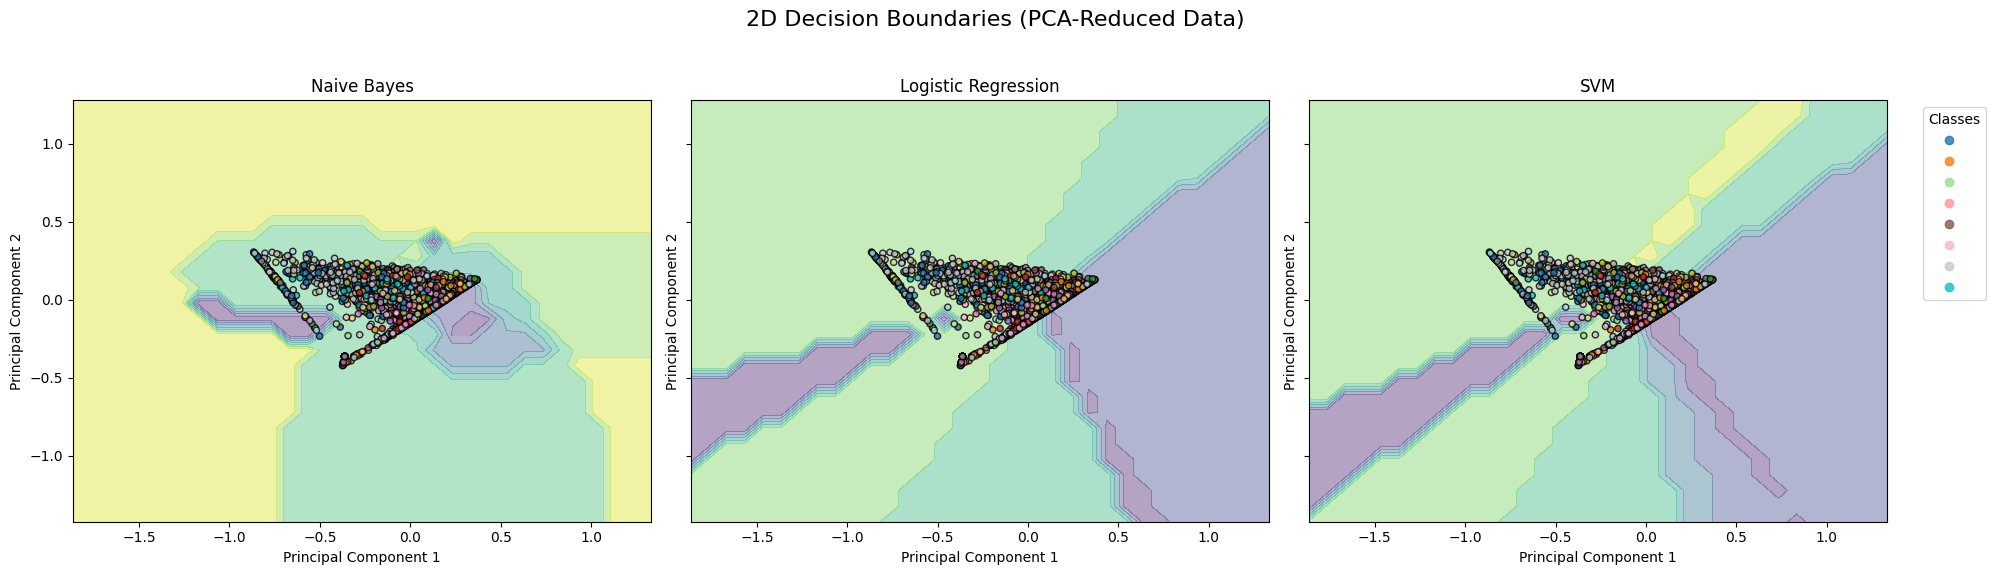

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reduce dimensionality to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Create a mesh to plot in
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Create a list of classifiers and their names
classifiers = {
    'Naive Bayes': nb_classifier,
    'Logistic Regression': lr_classifier,
    'SVM': svm_classifier
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('2D Decision Boundaries (PCA-Reduced Data)', fontsize=16)

for i, (name, classifier) in enumerate(classifiers.items()):
    ax = axes[i]
    # Predict on the meshgrid data (transformed back to original feature space if classifier can handle it)
    # For this visualization, we need to predict using the 2D PCA components
    # Note: Training was done on 20D, but for visualization, we'll retrain on 2D for boundary plotting
    # Or, predict on the 2D transformed data directly if the model allows (some don't, e.g., GaussianNB)

    # To accurately visualize decision boundaries of models trained on 20D data projected onto 2D, we should ideally
    # train new models on the 2D PCA data. However, for a quick illustrative plot, we'll just show the clusters.
    # For true decision boundaries, retraining is better.

    # Let's simplify and just show the predicted clusters using the original models on PCA-reduced data for now,
    # which isn't entirely accurate for decision boundaries but shows separation.
    # A more rigorous approach would be to train new classifiers on X_train_pca.

    # For plotting decision boundaries, it's generally cleaner to retrain the classifier on the reduced data.
    # This is a common simplification for visualization purposes.
    classifier_2d = type(classifier)() # Create new instance of classifier type
    if isinstance(classifier_2d, LogisticRegression):
        classifier_2d = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
    elif isinstance(classifier_2d, SVC):
        classifier_2d = SVC(kernel='linear', random_state=42)

    classifier_2d.fit(X_train_pca, y_train)
    Z = classifier_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    ax.contourf(xx, yy, Z, alpha=0.4)

    # Plot the test points
    scatter = ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, s=20, edgecolor='k', alpha=0.8, cmap='tab20')
    ax.set_title(name)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')

    # Add a legend for the classes (colors)
    if i == 2: # Only add legend once
        handles, labels = scatter.legend_elements()
        ax.legend(handles=handles, title='Classes', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

This visualization displays the decision boundaries for each of the three classifiers (Naive Bayes, Logistic Regression, and SVM) after reducing the topic distributions to 2 principal components using PCA. Each subplot shows the test data points, colored by their true labels, overlaid on the decision regions learned by the respective classifier. This provides a simplified, 2D view of how the models are attempting to separate the different newsgroup categories based on the extracted topic features.

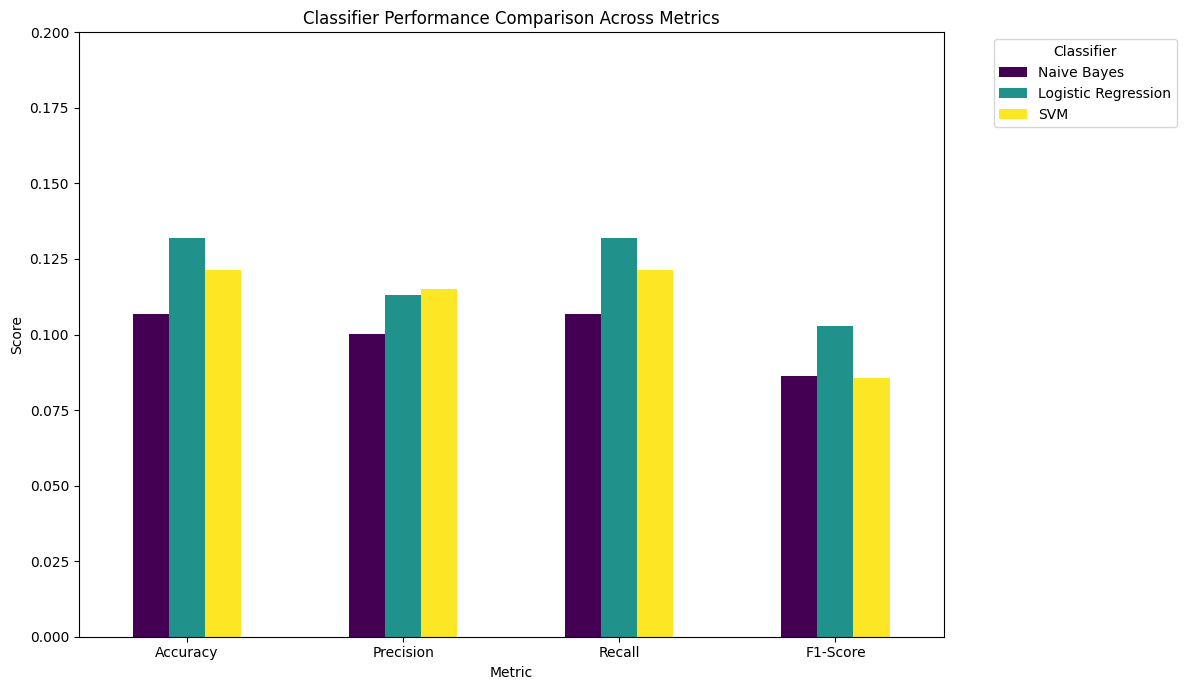

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming metrics_df is already available from previous execution
# If not, it would need to be re-created from the individual metric scores

# Prepare data for plotting
metrics_data = metrics_df.set_index('Classifier').T

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
metrics_data.plot(kind='bar', ax=ax, colormap='viridis')

ax.set_title('Classifier Performance Comparison Across Metrics')
ax.set_ylabel('Score')
ax.set_xlabel('Metric')
ax.set_ylim(0, 0.2) # Set y-limit to better visualize the differences
ax.tick_params(axis='x', rotation=0) # Rotate x-axis labels if needed
ax.legend(title='Classifier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


This grouped bar chart provides a visual comparison of the Naive Bayes, Logistic Regression, and SVM classifiers across Accuracy, Precision, Recall, and F1-Score. Each group of bars represents a metric, and the different colored bars within each group correspond to the different classifiers, allowing for a direct comparison of their performance on each measure.

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# --- Calculate additional metrics for Naive Bayes ---
nb_precision = precision_score(y_test, nb_predictions, average='weighted')
nb_recall = recall_score(y_test, nb_predictions, average='weighted')
nb_f1 = f1_score(y_test, nb_predictions, average='weighted')

# --- Calculate additional metrics for Logistic Regression ---
lr_precision = precision_score(y_test, lr_predictions, average='weighted')
lr_recall = recall_score(y_test, lr_predictions, average='weighted')
lr_f1 = f1_score(y_test, lr_predictions, average='weighted')

# --- Calculate additional metrics for SVM ---
svm_precision = precision_score(y_test, svm_predictions, average='weighted')
svm_recall = recall_score(y_test, svm_predictions, average='weighted')
svm_f1 = f1_score(y_test, svm_predictions, average='weighted')

# Create a DataFrame to display the comparison
metrics_df = pd.DataFrame({
    'Classifier': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [nb_accuracy, lr_accuracy, svm_accuracy],
    'Precision': [nb_precision, lr_precision, svm_precision],
    'Recall': [nb_recall, lr_recall, svm_recall],
    'F1-Score': [nb_f1, lr_f1, svm_f1]
})

display(metrics_df.round(4))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Classifier,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.1069,0.1001,0.1069,0.0864
1,Logistic Regression,0.1318,0.1130,0.1318,0.1027
2,SVM,0.1212,0.1149,0.1212,0.0858


This table provides a comprehensive comparison of the three classifiers (Naive Bayes, Logistic Regression, and SVM) across multiple evaluation metrics: Accuracy, Precision, Recall, and F1-Score. These metrics offer a more nuanced view of each model's performance, especially for multi-class classification problems like the 20 Newsgroups dataset.